# **Sales Analysis**

In [74]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [75]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [76]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [77]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
878772,2025-02-15 16:04:02.132471,2025,2,Sat,Afternoon,Yes,Brian Martinez,Male,62,55-64,Regular,United Kingdom,Completed,Sports,Accessories,123.05,Premium,4,Bulk,492.20,24.61,5,Low Discount,Yes,467.59,High,231.15,49.43,Bank Transfer,Next Day,7.15,1.53,4,Standard,United Kingdom,Domestic,4,35.00,Medium,No,33.10,Medium,8,No,95.60,High,Tablet,Instagram,Social
897098,2025-08-27 02:37:05.656605,2025,8,Wed,Night,No,Wanda Hood,Female,48,45-54,Regular,Germany,Cancelled,Sports,Accessories,191.41,Premium,3,Small Basket,574.23,57.42,10,Low Discount,Yes,516.81,High,200.01,38.70,Credit Card,Express,20.66,4.00,12,Slow,Germany,Domestic,1,49.30,Medium,No,33.10,Medium,12,No,88.40,High,Tablet,Facebook,Social
200988,2025-05-08 20:53:02.759582,2025,5,Thu,Evening,No,Larry Stanton,Male,53,45-54,Regular,Germany,Completed,Clothing,Mens Wear,93.03,Mid-Range,5,Bulk,465.15,0.00,0,No Discount,No,465.15,High,218.25,46.92,Bank Transfer,Next Day,10.56,2.27,4,Standard,Germany,Domestic,4,47.00,Medium,No,24.90,Medium,14,No,92.20,High,Desktop,Organic,Email
616495,2024-09-21 06:36:33.671099,2024,9,Sat,Morning,Yes,Whitney Shannon MD,Female,18,18-24,Regular,Italy,Completed,Sports,Outdoor,179.64,Premium,1,Single,179.64,17.96,10,Low Discount,Yes,161.68,Medium,36.44,22.54,Apple Pay,Next Day,16.47,10.19,5,Standard,Italy,Domestic,1,56.00,Medium,No,21.30,Medium,14,Yes,99.50,High,Tablet,Facebook,Email
32421,2025-05-27 02:04:36.279265,2025,5,Tue,Night,No,Joseph Vance,Male,62,55-64,VIP,Spain,Processing,Clothing,Womens Wear,121.23,Premium,1,Single,121.23,6.06,5,Low Discount,Yes,115.17,Medium,59.50,51.66,Credit Card,Express,3.07,2.67,13,Slow,Spain,Domestic,2,10.50,Low,Yes,51.40,High,10,Yes,36.40,Medium,Desktop,Email,Search
113969,2024-06-22 13:52:15.446952,2024,6,Sat,Afternoon,Yes,Kim Perez,Female,73,65+,Regular,Netherlands,Completed,Sports,Gym Equipment,51.78,Mid-Range,3,Small Basket,155.34,0.00,0,No Discount,No,155.34,Medium,76.80,49.44,PayPal,Express,6.58,4.24,1,Fast,Netherlands,Domestic,4,64.00,Medium,No,23.00,Medium,15,Yes,14.20,Low,Mobile,Instagram,Email
797468,2025-06-22 19:24:19.939858,2025,6,Sun,Evening,Yes,Jennifer Hendricks,Female,63,55-64,Regular,United Kingdom,Completed,Electronics,Accessories,257.25,Luxury,5,Bulk,"1,286.25",64.31,5,Low Discount,Yes,"1,221.94",Very High,632.79,51.79,Debit Card,Next Day,22.75,1.86,10,Slow,United Kingdom,Domestic,3,3.00,Low,No,59.30,High,8,No,94.80,High,Mobile,Facebook,Referral
708381,2024-11-12 16:03:08.882318,2024,11,Tue,Afternoon,No,Mark Turner,Male,45,45-54,Premium,Belgium,Returned,Sports,Accessories,80.83,Mid-Range,1,Single,80.83,20.21,25,High Discount,Yes,60.62,Low,13.61,22.45,PayPal,Next Day,0.52,0.86,4,Standard,Belgium,Domestic,2,99.90,High,No,50.80,High,3,Yes,79.50,High,Desktop,Facebook,Direct
69404,2025-01-18 06:31:37.419254,2025,1,Sat,Morning,Yes,Wesley Taylor,Male,44,35-44,Regular,Spain,Completed,Health,Supplements,130.19,Premium,1,Single,130.19,0.00,0,No Discount,No,130.19,Medium,65.01,49.93,PayPal,Express,8.94,6.87,12,Slow,Spain,Domestic,2,40.60,Medium,No,41.50,High,12,Yes,6.50,Low,Tablet,Affiliate,Social
902483,2024-02-29 12:35:43.698099,2024,2,Thu,Afternoon,No,Dale Ford,Male,66,65+,Regular,France,Completed,Sports,Sports Wear,138.35,Premium,4,Bulk,553.40,55.34,10,Low Discount,Yes,498.06,High,179.58,36.06,Apple Pay,Next Day,4.

## 1.1 Revenue by Time

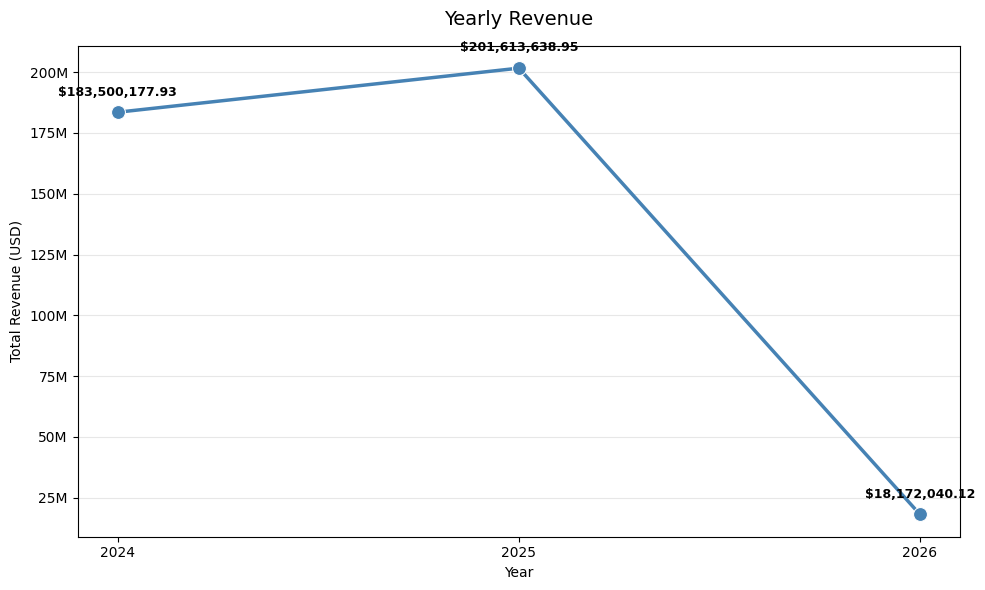

In [78]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    sales_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

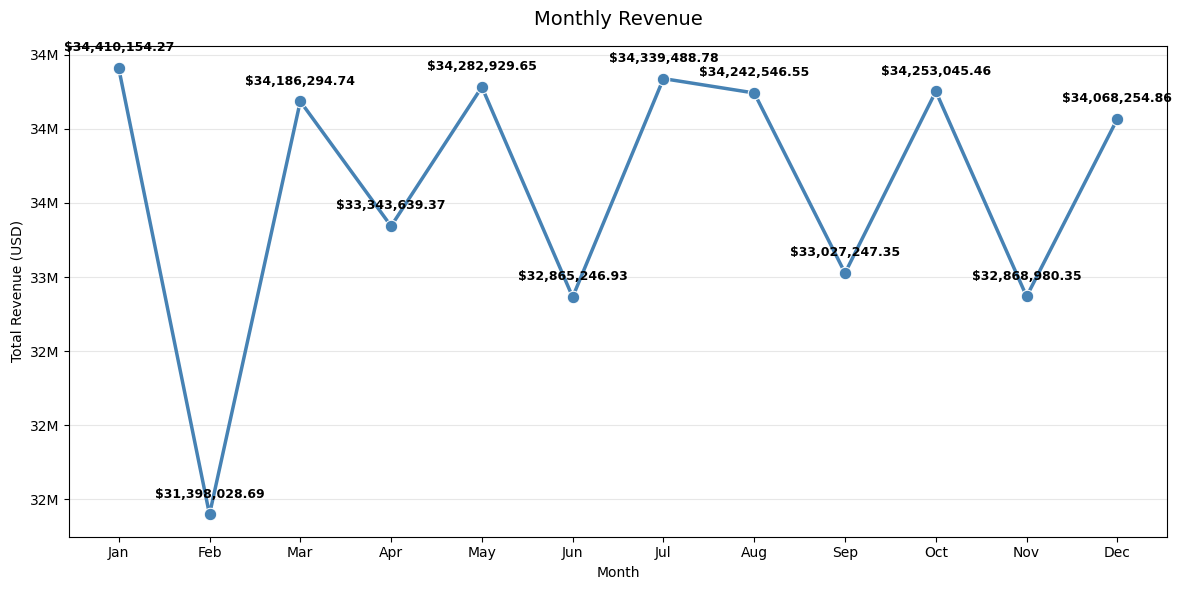

In [79]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

sales_df['order_month'] = sales_df['order_month'].map(month_map)

monthly_revenue = (
    sales_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

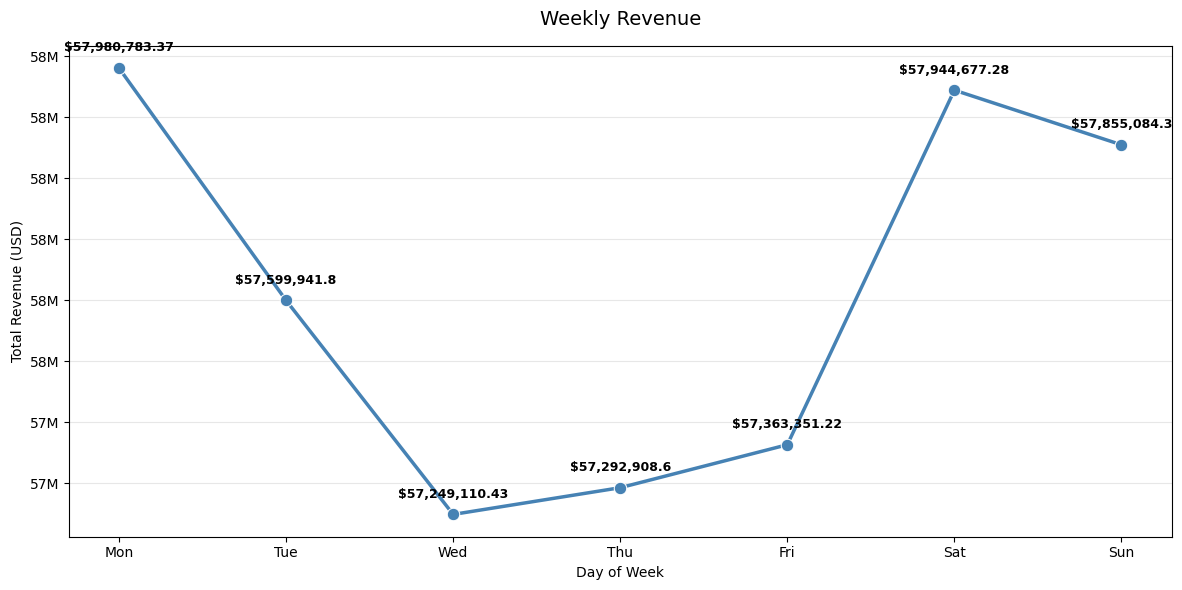

In [80]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

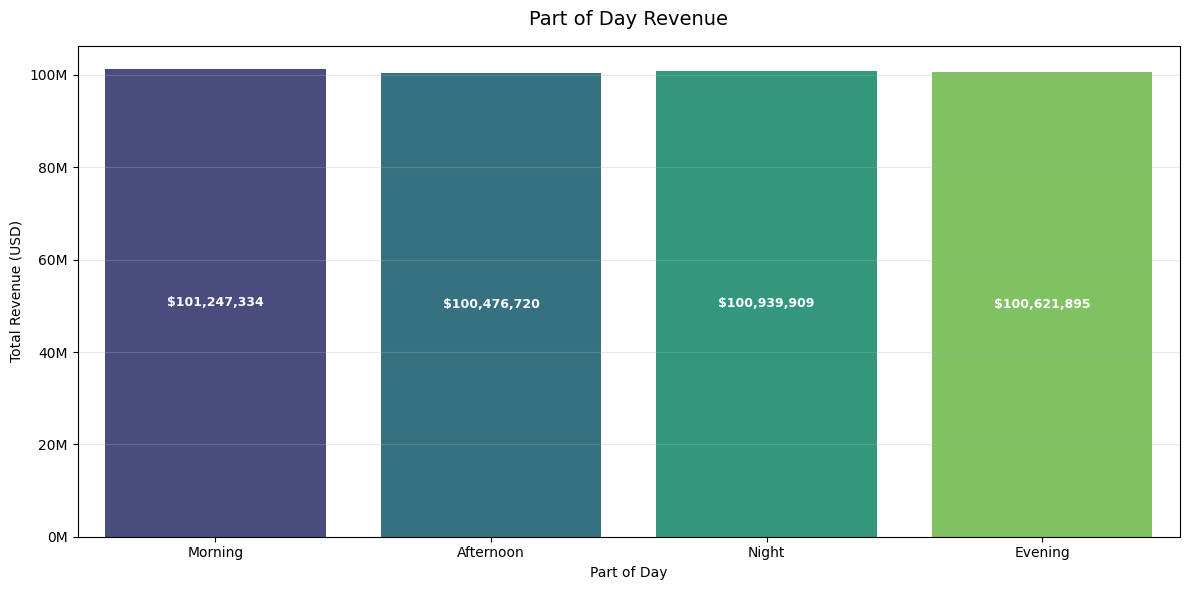

In [81]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    sales_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

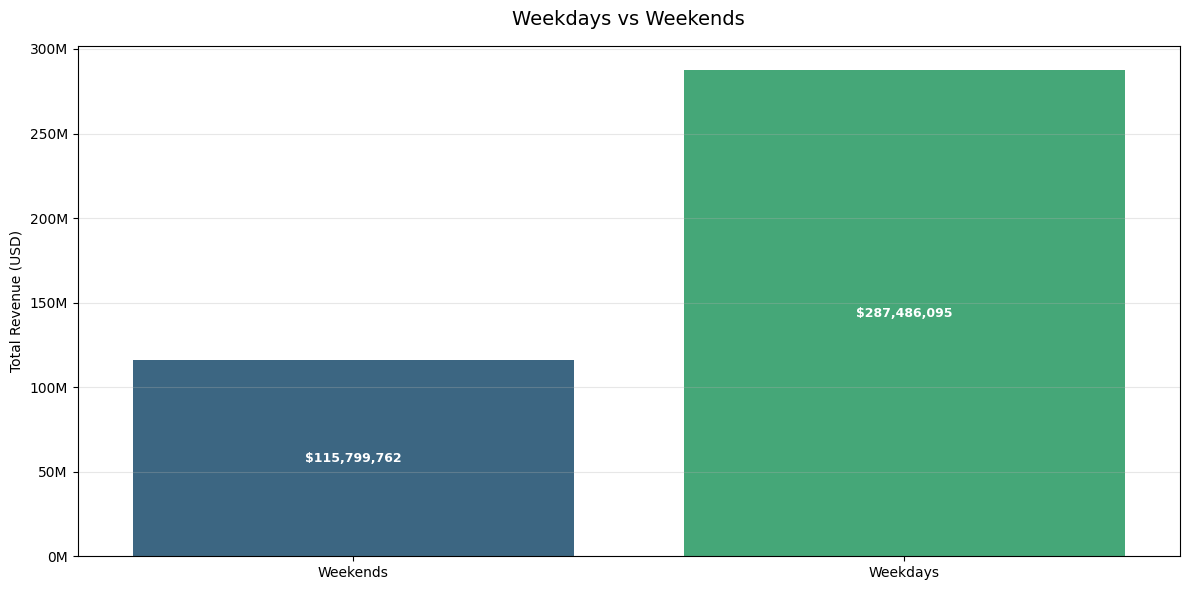

In [82]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    sales_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

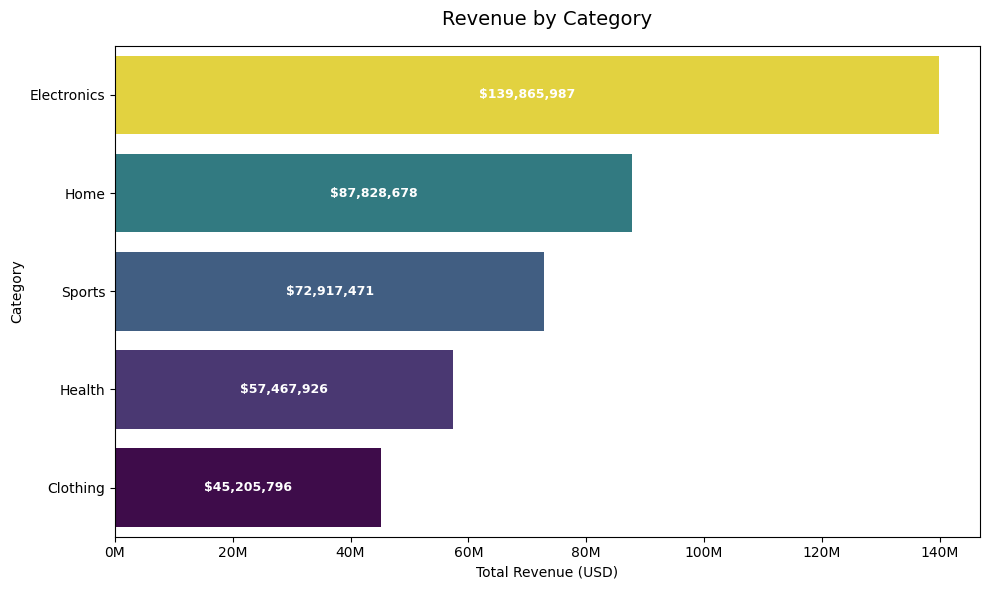

In [83]:
# 1.2.1 Revenue per Category

category_revenue = (
    sales_df.groupby('category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

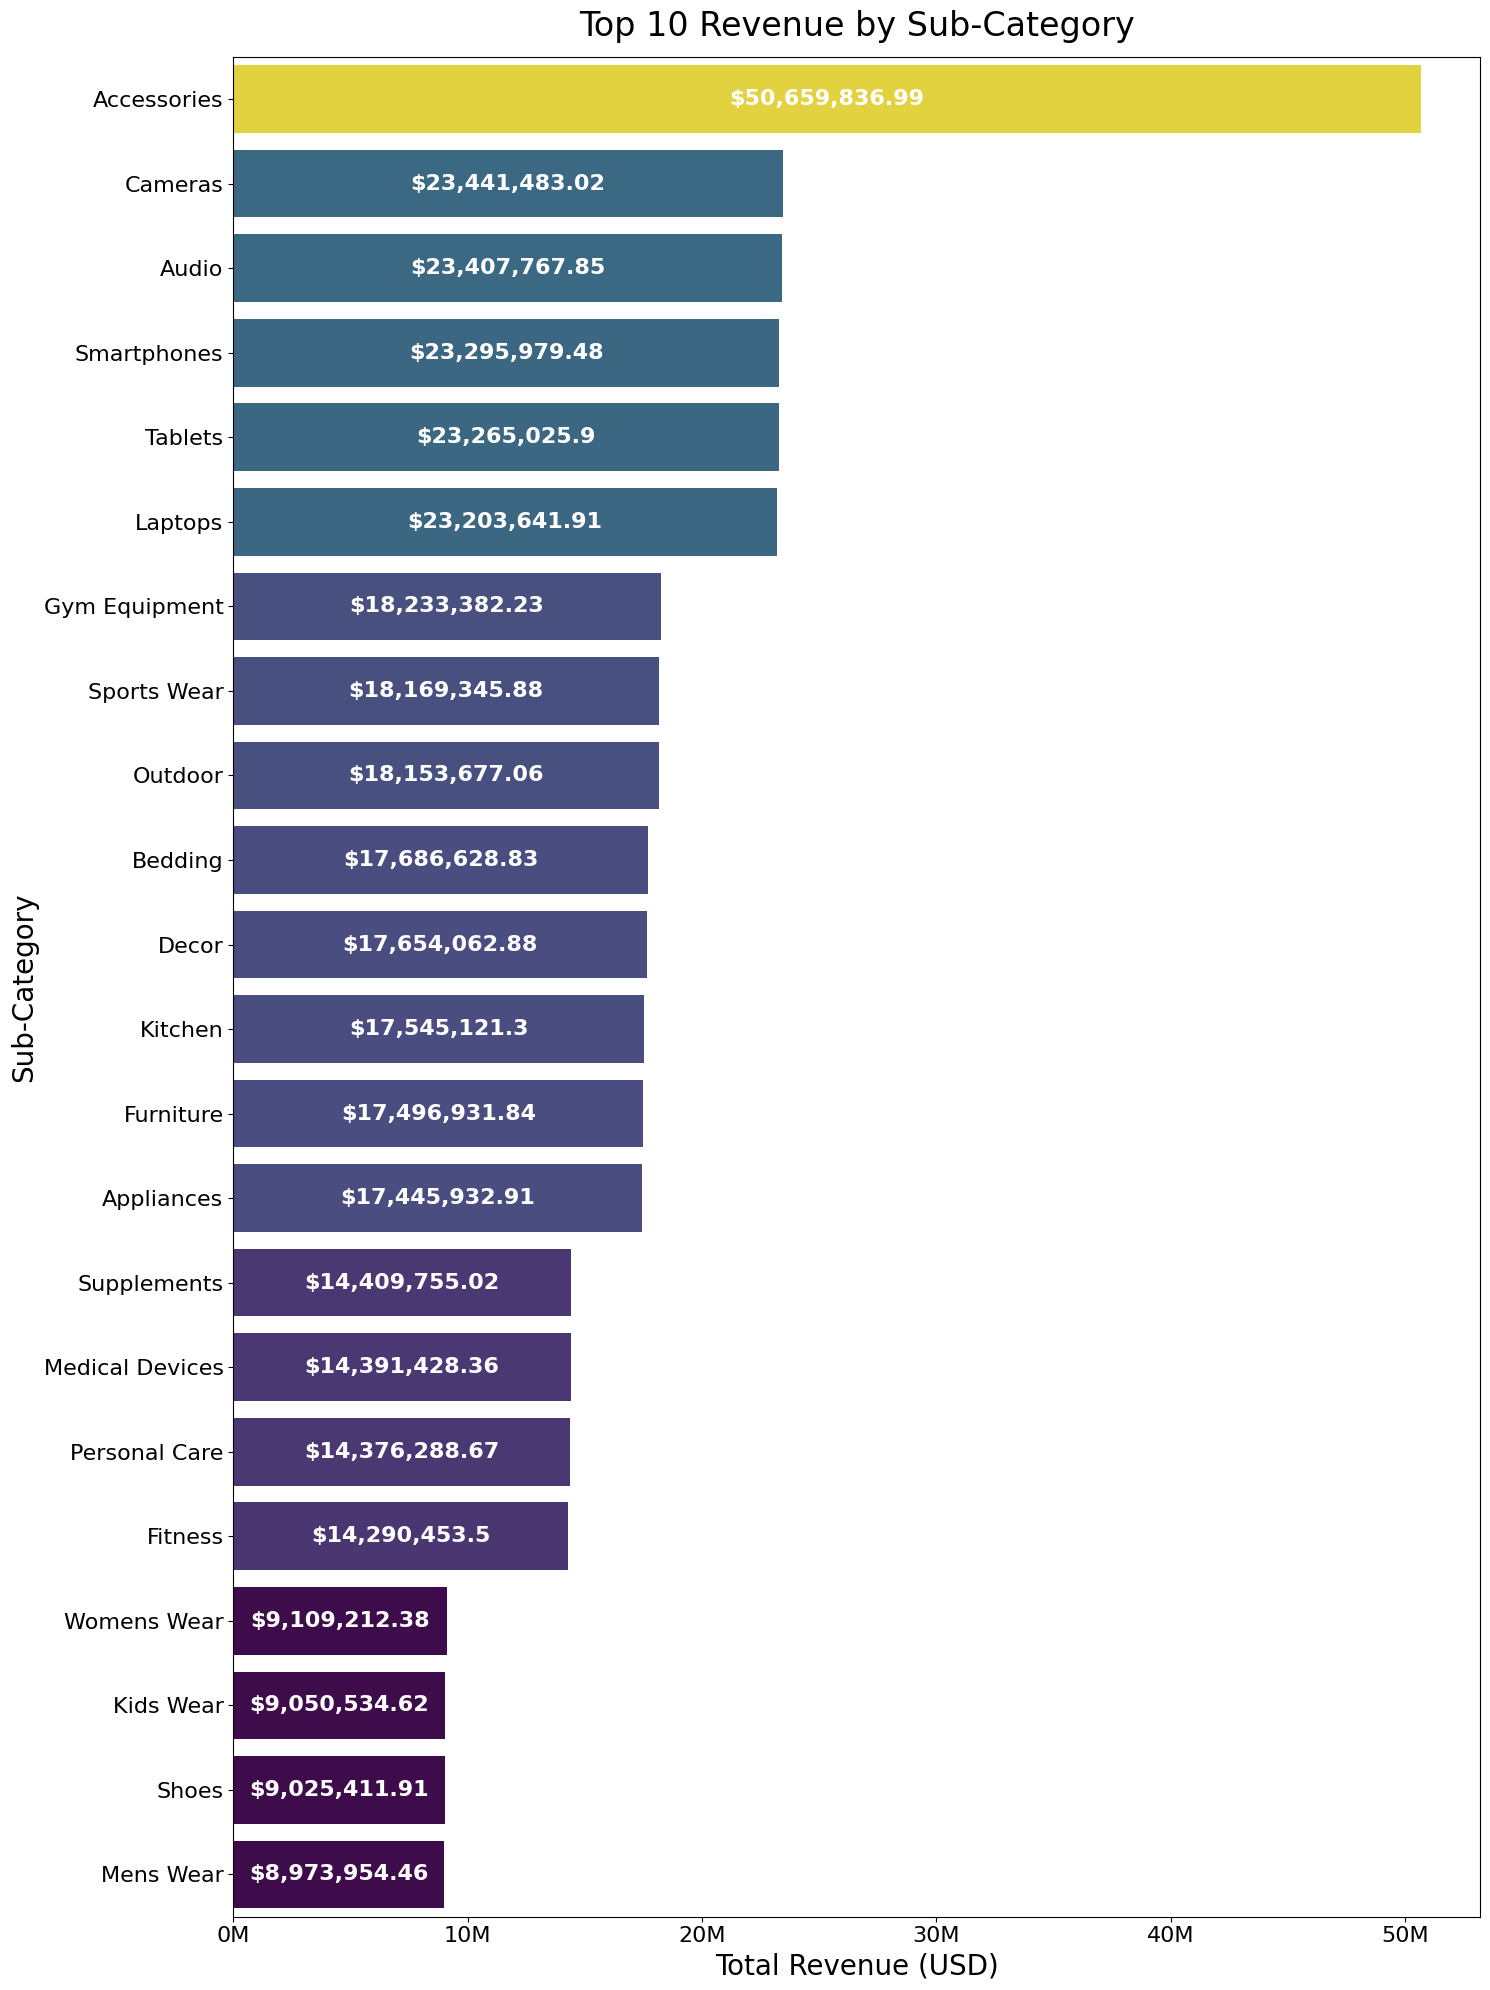

In [84]:
# 1.2.1 Top 10 Revenue Sub Category

subcategory_revenue = (
    sales_df.groupby('sub_category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

## 1.3 Revenue by Country

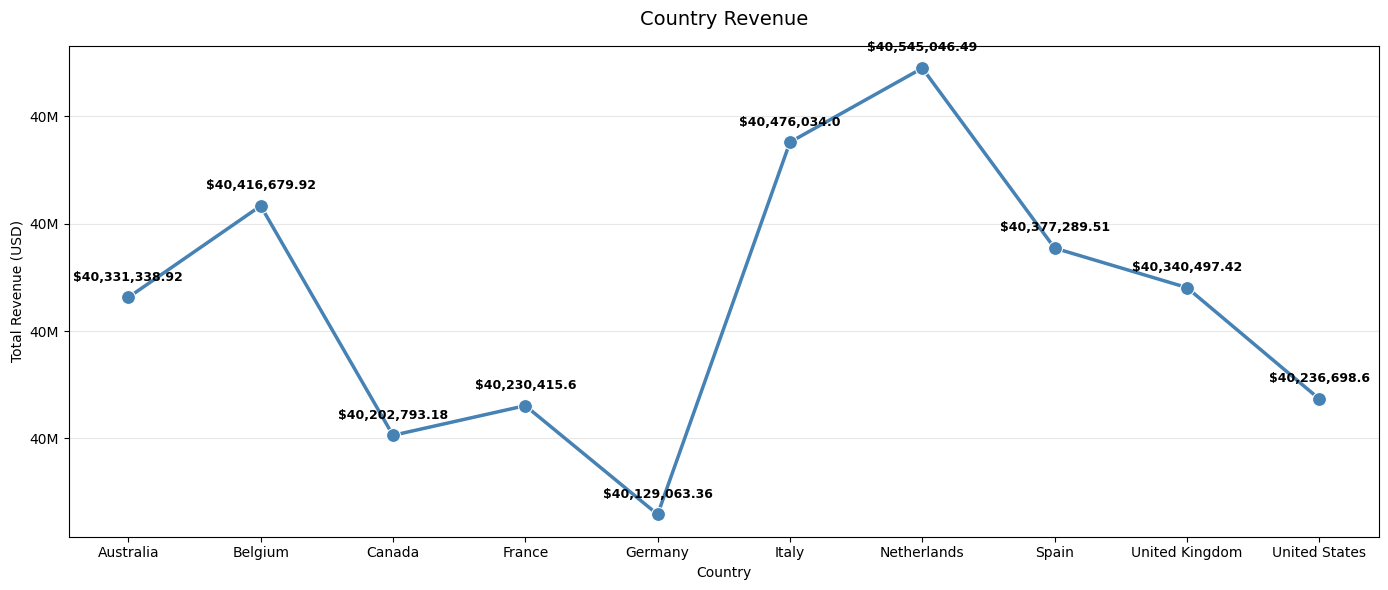

In [85]:
# 1.3.1 Country Revenue

country_revenue = (
    sales_df.groupby('country')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=country_revenue,
    x='country',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(country_revenue['country'], country_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.title('Country Revenue', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.xticks(country_revenue['country'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

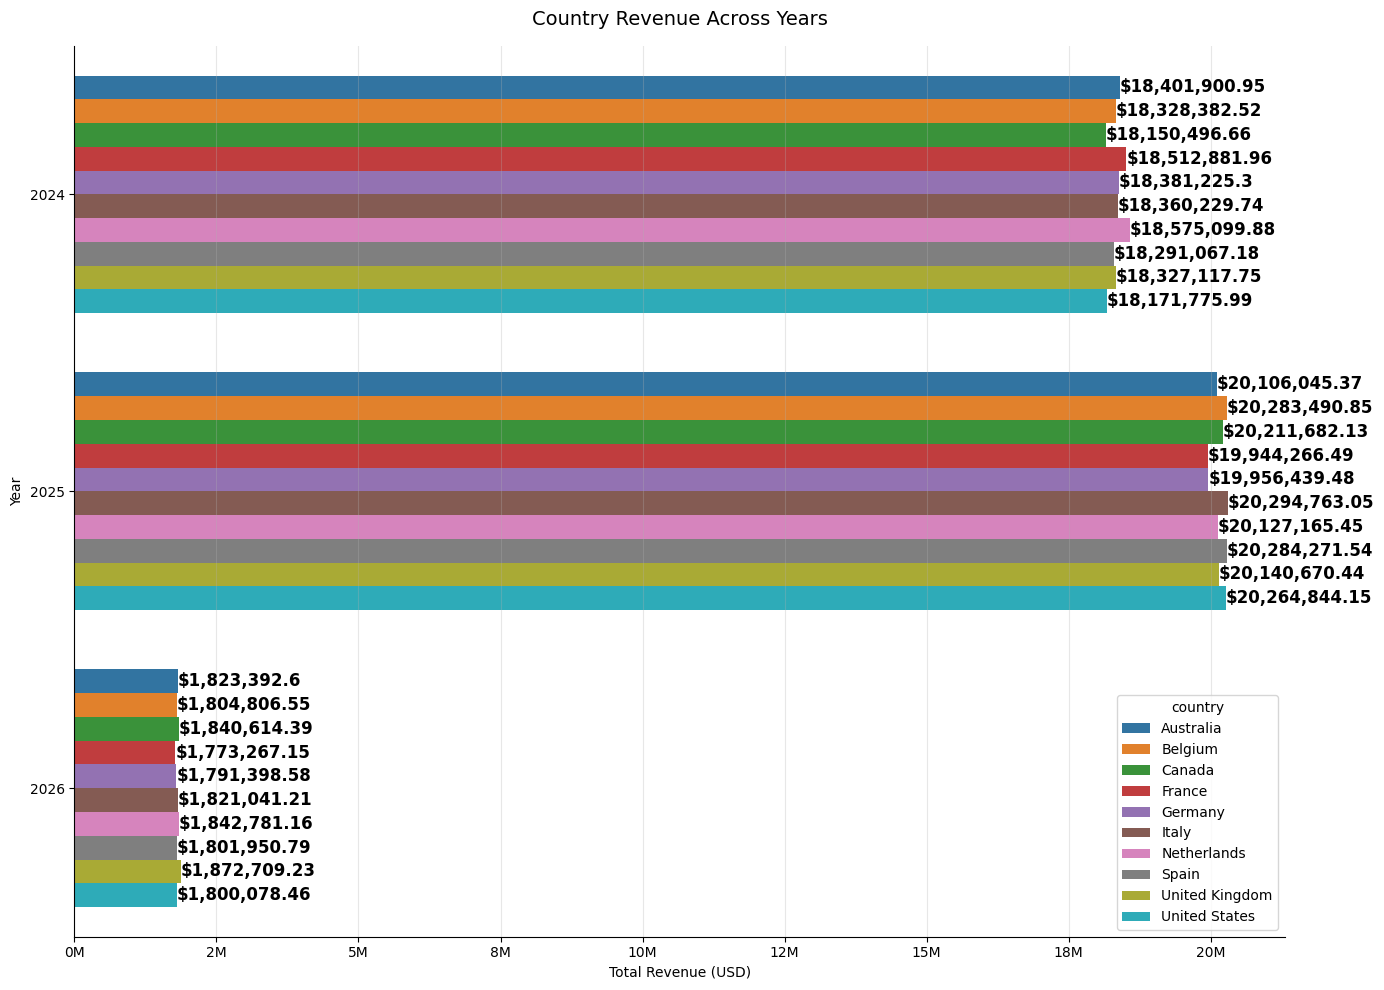

In [86]:
# 1.3.1 Country Revenue Across Years

country_yearly_revenue = sales_df.groupby(
    ['order_year', 'country']
)['revenue_usd'].sum().reset_index()

plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=country_yearly_revenue,
    x='revenue_usd',
    y='order_year',
    palette='tab10',
    hue='country',
    orient='h'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold',
    )
    

plt.title('Country Revenue Across Years', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Year')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Revenue by Order Value Segment

C:\Users\User\AppData\Local\Temp\ipykernel_29984\426723021.py:16: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(


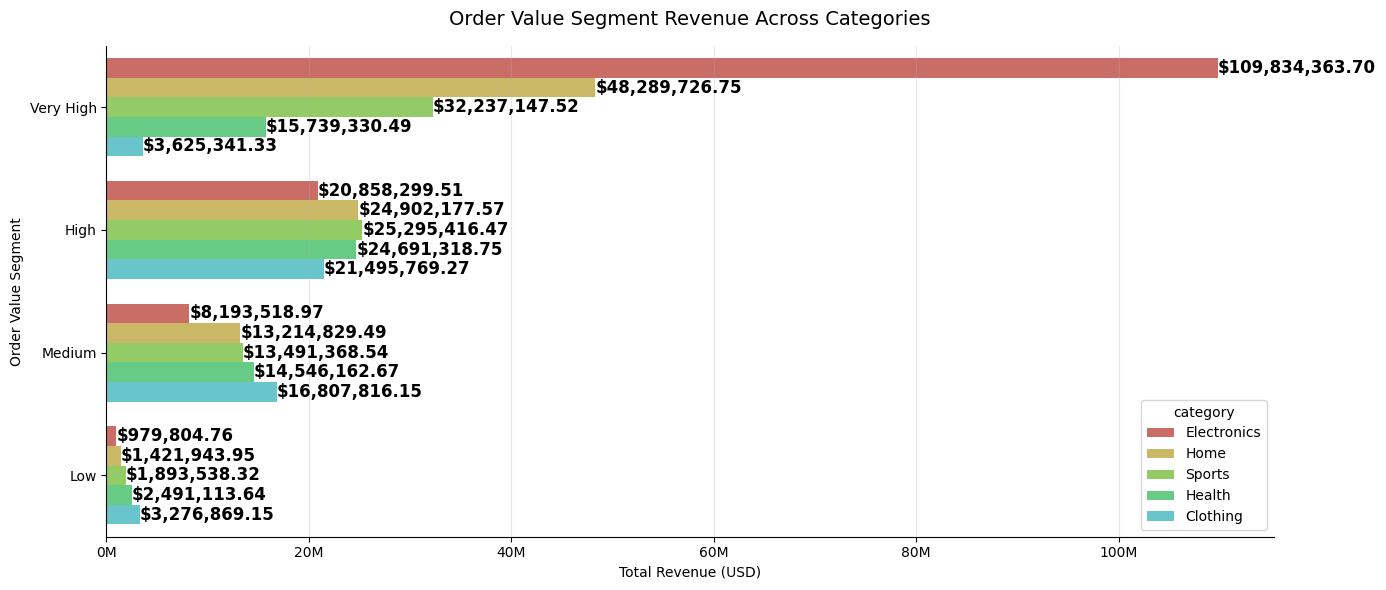

In [94]:
# 1.4.1 Order Value Segment Revenue Across Categories

order_value_segment_revenue = sales_df.groupby(
    ['order_value_segment', 'category']
)['revenue_usd'].sum().reset_index().sort_values('revenue_usd')


order_value_segment_revenue['order_value_segment'] = pd.Categorical(
    order_value_segment_revenue['order_value_segment'],
    categories=['Very High', 'High', 'Medium', 'Low'],
    ordered=True
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='revenue_usd',
    y='order_value_segment',
    hue='category',
    palette=sns.color_palette('hls',8),
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Order Value Segment Revenue Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 Customers

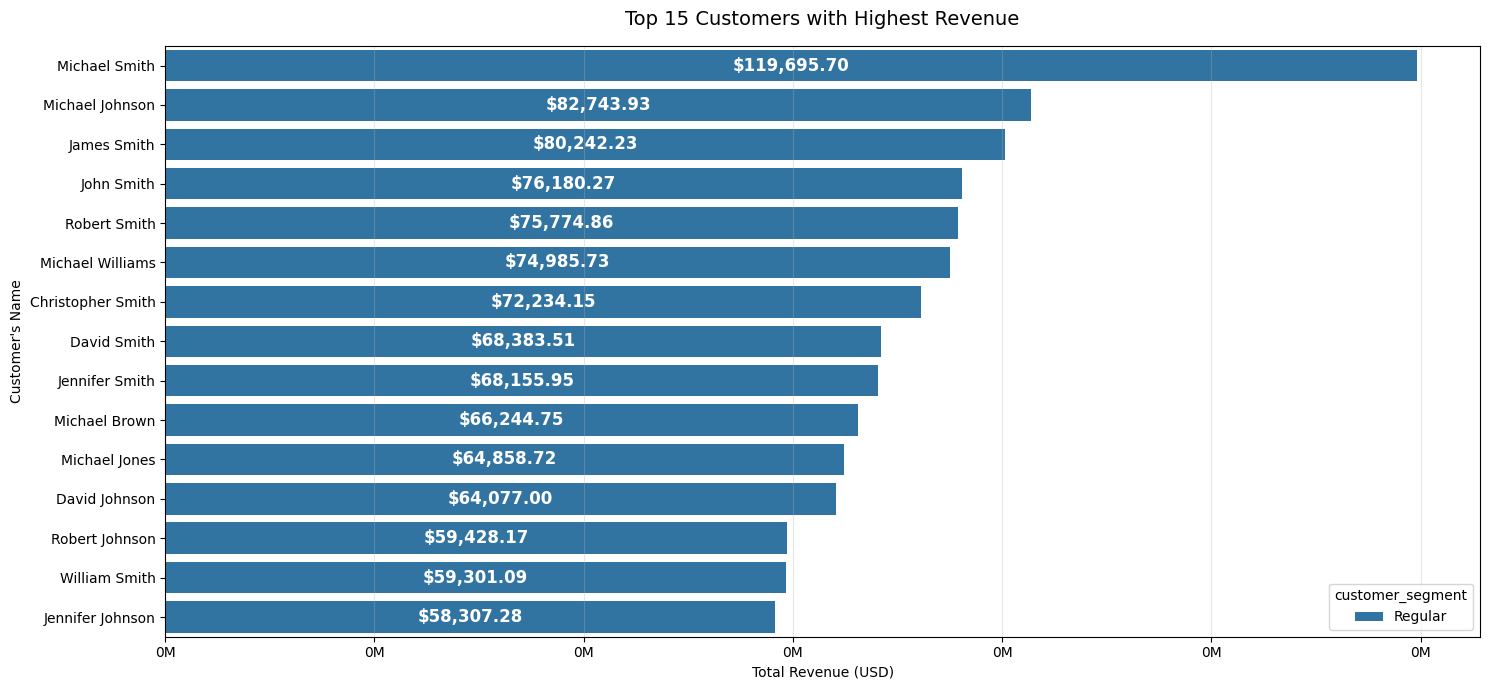

In [88]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment

customers_highest_revenue = sales_df.groupby(['customer_name','customer_segment'])['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customers_highest_revenue,
    x='revenue_usd',
    y='customer_name',
    hue='customer_segment',
    orient='h',
    palette='tab10'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Top 15 Customers with Highest Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Customer's Name")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

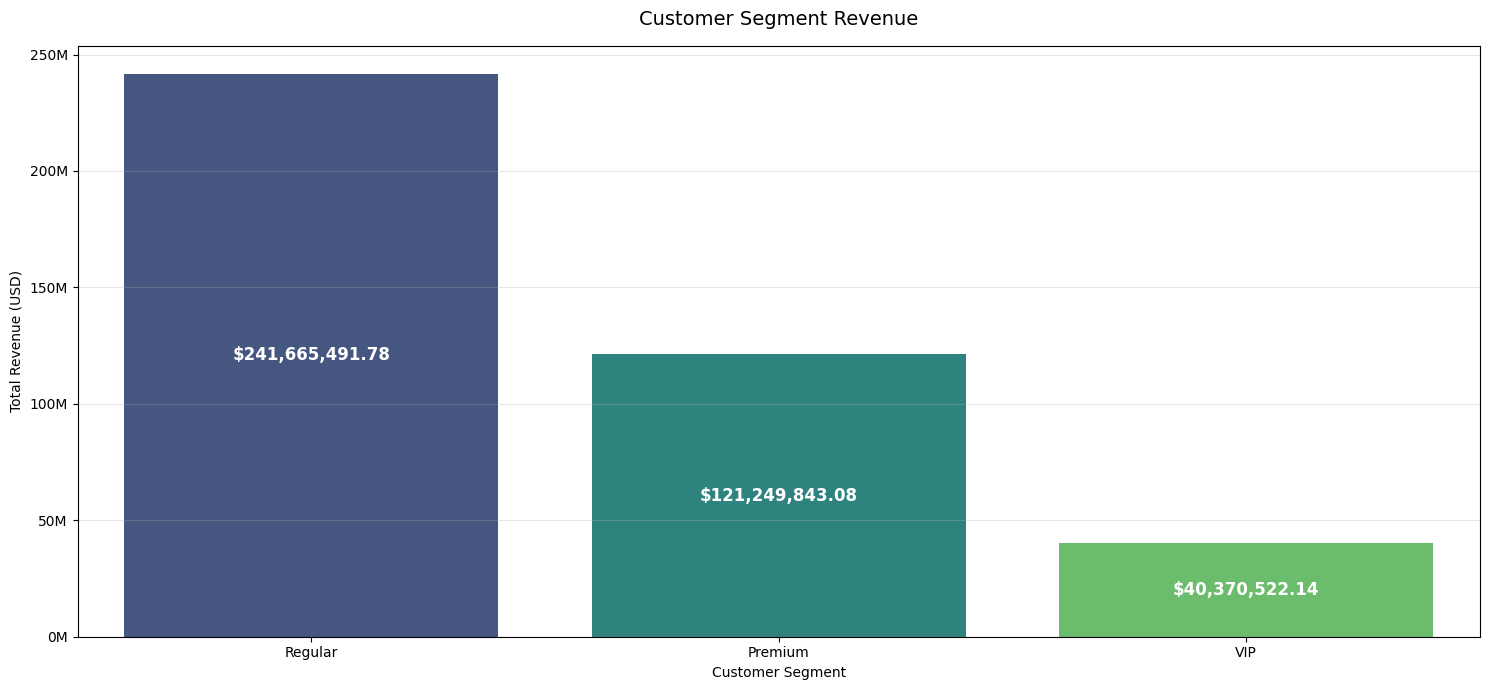

In [89]:
# 1.5.2 Customer Segment Revenue

customer_segment_revenue = sales_df.groupby('customer_segment')['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_usd',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Customer Segment Revenue', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Total Revenue (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)